In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [36]:
# by STEFAN SMID
# read file from Github

username = "datagus"
repository = "ASDA2025"
directory = "datasets/Fish.csv"
file_path = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"

In [37]:
fish_df = pd.read_csv(file_path)
fish_df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [38]:
# first basic data exploration
fish_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [39]:
# descriptive statistics
fish_df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [40]:
# only categorical columns
fish_df.describe(include=['object'])


,Species
count,159
unique,7
top,Perch
freq,56


In [41]:
# check for missing values
fish_df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [42]:
# Check for duplicate rows
fish_df.duplicated().any()

np.False_

## 5. Analysis - Research question
→ Linear regression steps

### Question/hypothesis
estimate the weight of fish
based on their length, height, width, and species

Correlation Matrix and Multicolinearity Check

In [75]:
# Creating a dummy variable for Species (numbers only)
fish_df['Species'] = fish_df['Species'].astype('category').cat.codes


,Weight,Length1,Length2,Length3,Height,Width,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish
0,5.488938,23.2,25.4,30.0,11.5200,4.0200,False,False,False,False,False,False
1,5.669881,24.0,26.3,31.2,12.4800,4.3056,False,False,False,False,False,False
2,5.828946,23.9,26.5,31.1,12.3778,4.6961,False,False,False,False,False,False
3,5.894403,26.3,29.0,33.5,12.7300,4.4555,False,False,False,False,False,False
4,6.063785,26.5,29.0,34.0,12.4440,5.1340,False,False,False,False,False,False


In [43]:
# Calculate the correlation matrix without categorical variables
correlation_matrix = fish_df.select_dtypes(include=['number']).corr()
correlation_matrix

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000


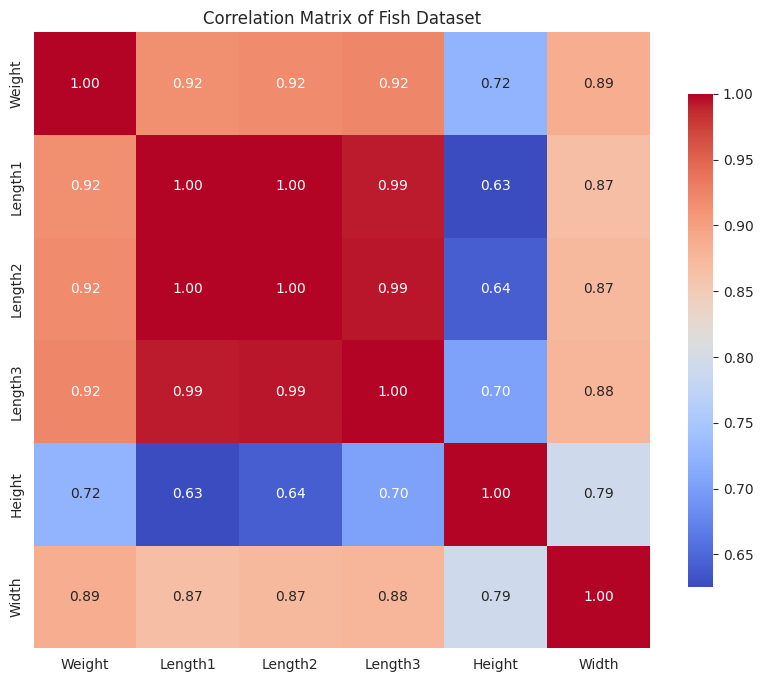

In [44]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 8))
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Fish Dataset')
plt.show()



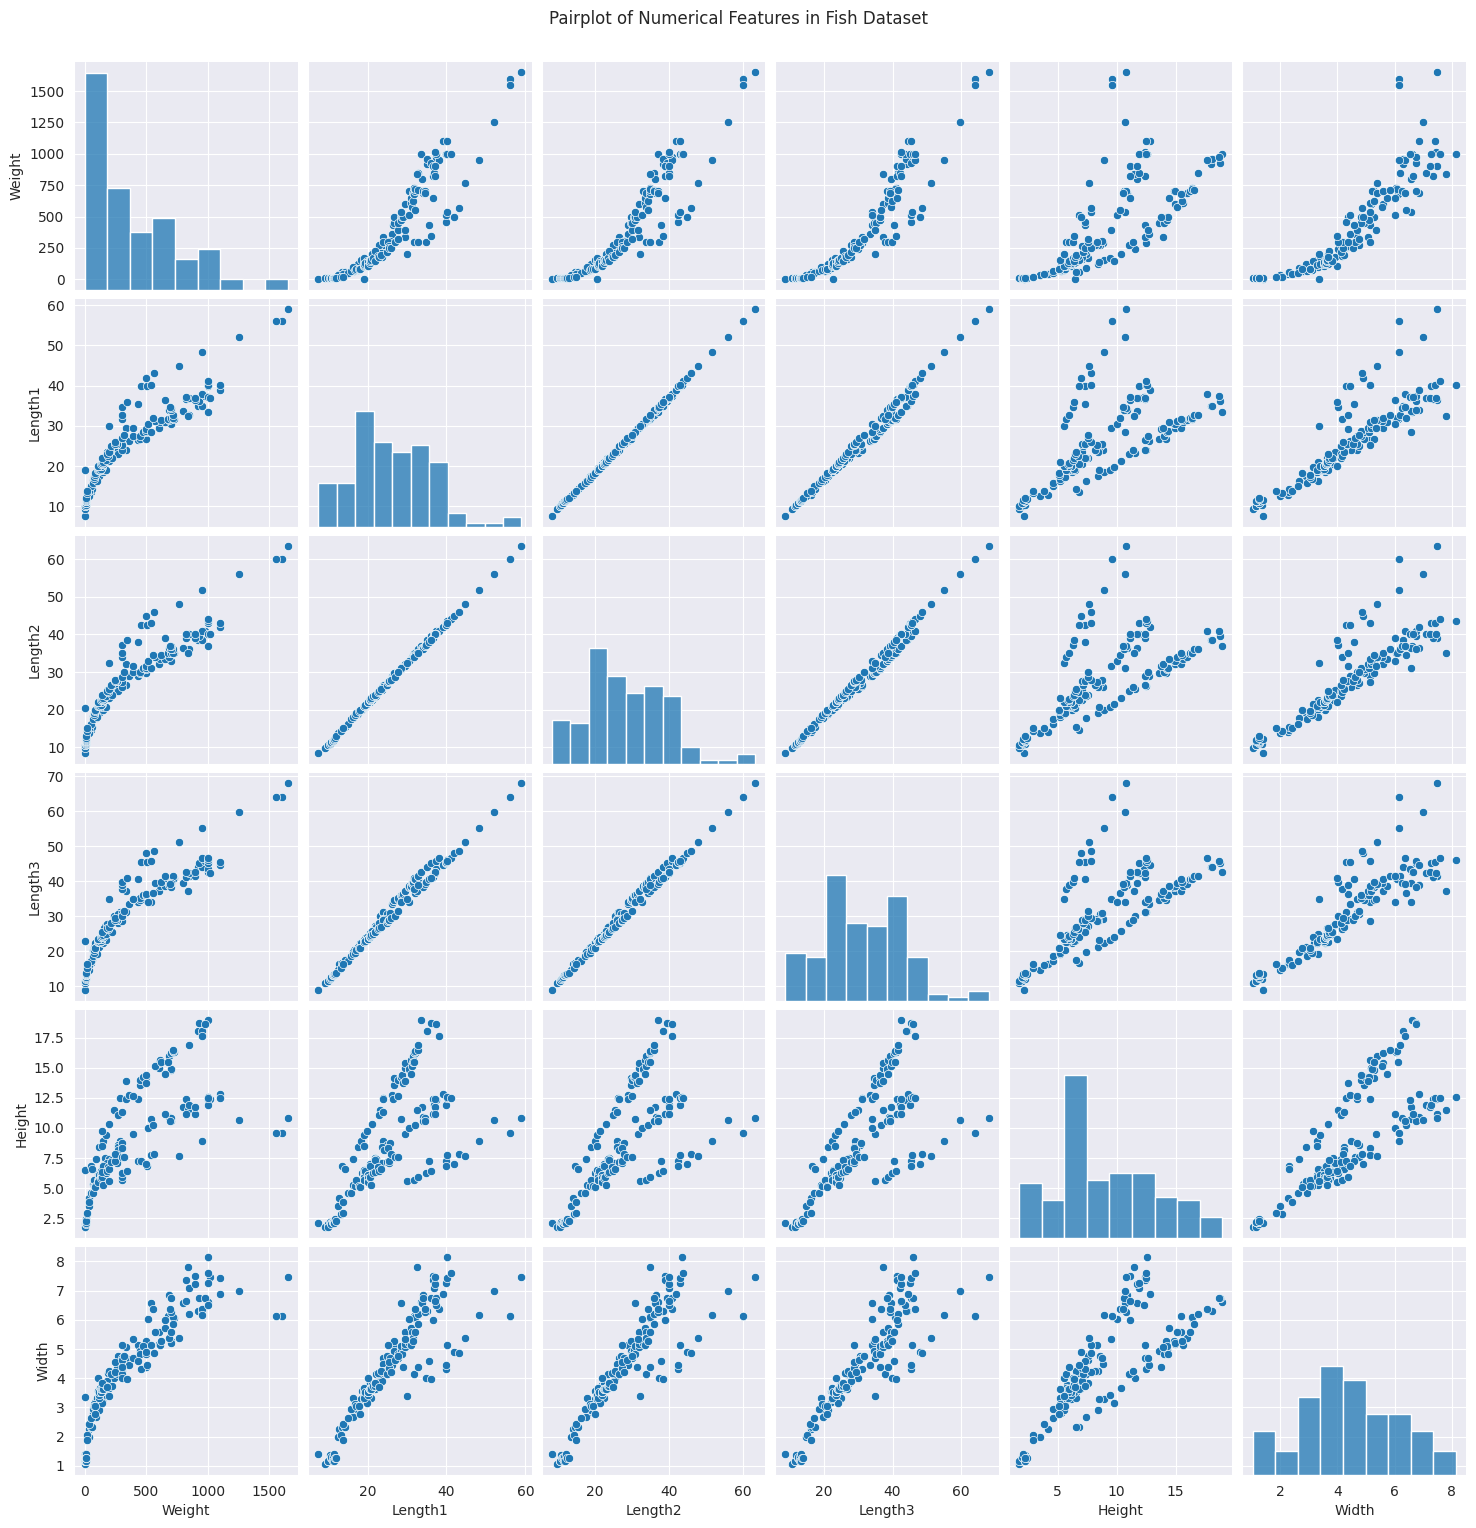

In [45]:
# now correlation plot with heatmap and distribution over the diagonal
sns.pairplot(fish_df.select_dtypes(include=['number']))
plt.suptitle('Pairplot of Numerical Features in Fish Dataset', y=1.02)
plt.show()

### 2. Check assumptions: normal distribution of dependent variable?
--> if not transform


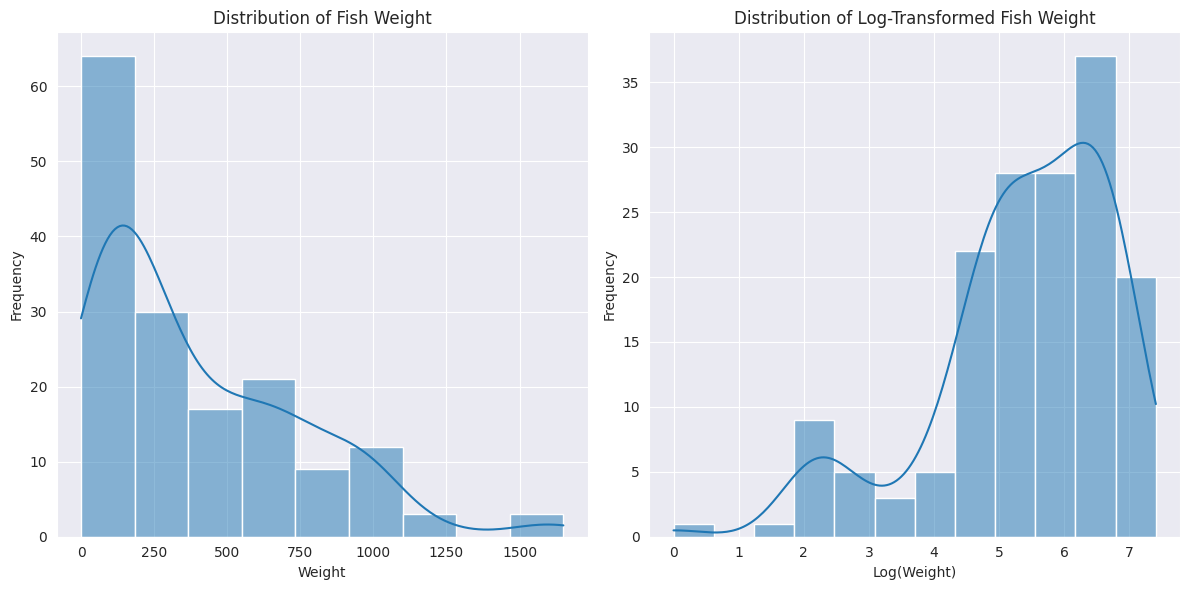

In [46]:
# weight is dependent variable
# as a tight matplotlib subplot layout

# Create a 1x2 subplot layout
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(fish_df['Weight'], kde=True)
plt.title('Distribution of Fish Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
# log transformation is needed
fish_df['Weight'] = fish_df['Weight'].apply(lambda x: np.log(x) if x > 0 else 0)

# log plot
plt.subplot(1, 2, 2)
sns.histplot(fish_df['Weight'], kde=True)
plt.title('Distribution of Log-Transformed Fish Weight')
plt.xlabel('Log(Weight)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 3. Check assumptions: multicollinearity (= redundancies among predictors)?
* with correlations
* with the variance inflation factor

* --> throw out redundant variables


In [74]:
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

# Select only numerical columns for VIF calculation
numerical_df = fish_df.select_dtypes(include=['number'])
vif_df = calculate_vif(numerical_df)
print(vif_df)

  Variable           VIF
0   Weight     50.560619
1  Length1  13866.656045
2  Length2  17423.312727
3  Length3   3448.387816
4   Height     76.362816
5    Width    105.270319


### How to interpret VIF:
- VIF = 1: No correlation between the predictor and other variables.
- 1 < VIF < 5: Moderate correlation, usually acceptable.
- VIF >= 5: High correlation, consider removing the variable.

In this case this means we should consider removing "Length1", "Length2", and "Length3" due to high multicollinearity.

In [49]:
# dropping Length1, Length2, Length3
fish_df_reduced = fish_df.drop(columns=['Length1', 'Length2', 'Length3'])
fish_df_reduced.head()

,Species,Weight,Height,Width
0,Bream,5.488938,11.5200,4.0200
1,Bream,5.669881,12.4800,4.3056
2,Bream,5.828946,12.3778,4.6961
3,Bream,5.894403,12.7300,4.4555
4,Bream,6.063785,12.4440,5.1340


In [50]:
# Recalculate VIF after dropping redundant variables
numerical_df_reduced = fish_df_reduced.select_dtypes(include=['number'])
vif_df_reduced = calculate_vif(numerical_df_reduced)
print(vif_df_reduced)

  Variable        VIF
0   Weight  36.006002
1   Height  15.049379
2    Width  42.030021


Still high VIF for all variables, but much better now.
We do proceed with the reduced dataset for further analysis.

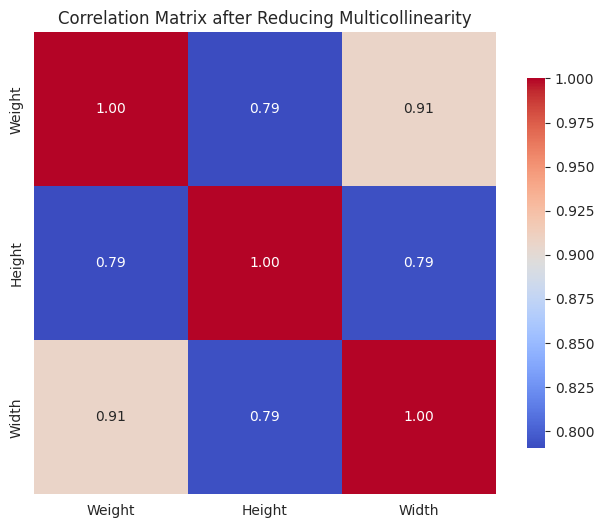

In [51]:
# Final correlation matrix after dropping redundant variables
correlation_matrix_reduced = fish_df_reduced.select_dtypes(include=['number']).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_reduced, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix after Reducing Multicollinearity')
plt.show()

### 4. Split the data in train and test data

In [52]:
X = fish_df_reduced.drop(columns=['Weight'])
y = fish_df_reduced['Weight']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 127 samples
Test set size: 32 samples


### 5. Preprocess the data:
- scale the numerical predictors - if you include multiple numerical predictors
- one hot encode the categorical predictors - if you include categorical predictors


In [55]:
# Preprocessing the data:
#   scale the numerical predictors - if you include multiple numerical predictors
#   one hot encode the categorical predictors - if you include categorical predictors

# Define the preprocessing steps
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Preprocessing complete.")

Preprocessing complete.


### 6. Train linear regression on training set

In [57]:
# Training linear regression on training set

model = LinearRegression()
model.fit(X_train_processed, y_train)
print("Model training complete.")

Model training complete.


### 7. Predict on test set and evaluate with metrics (e.g. MAE, RMSE, MAPE, R2))

In [64]:
y_pred = model.predict(X_test_processed)

# Calculate evaluation metrics
MAE = np.mean(np.abs(y_test - y_pred))
RMSE = np.sqrt(mean_squared_error(y_test, y_pred)) # Root Mean Squared Error (RMSE)
MAPE = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
R2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error (MAE) on Test Set: {MAE:.4f} \nRoot Mean Squared Error (RMSE) on Test Set: {RMSE:.4f} \nMean Absolute Percentage Error (MAPE) on Test Set: {MAPE:.2f}% \nR^2 Score on Test Set: {R2:.4f}")

Mean Absolute Error (MAE) on Test Set: 0.2266 
Root Mean Squared Error (RMSE) on Test Set: 0.2650 
Mean Absolute Percentage Error (MAPE) on Test Set: 4.74% 
R^2 Score on Test Set: 0.9714


### Plots
- scatterplot with regression line
- actual vs. predicted values
- histogram of residuals: normal distribution? → if not, investigate why not?

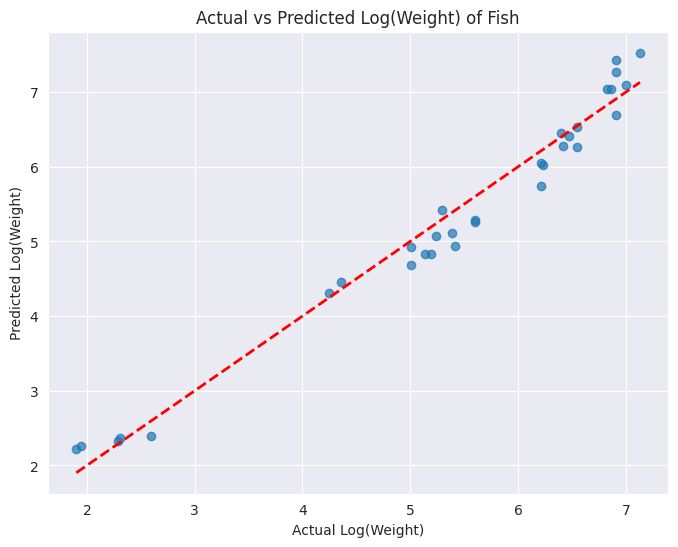

In [65]:
# Visualizing the predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Log(Weight)')
plt.ylabel('Predicted Log(Weight)')
plt.title('Actual vs Predicted Log(Weight) of Fish')
plt.show()

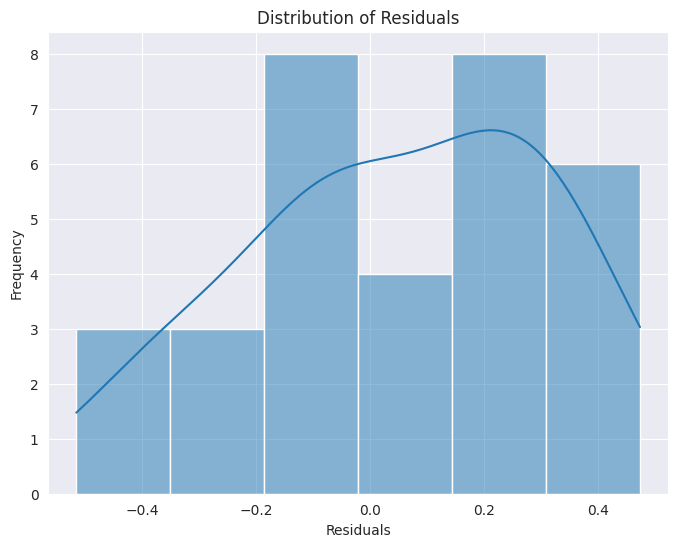

In [66]:
# Residuals plot checking for normal distribution of residuals
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

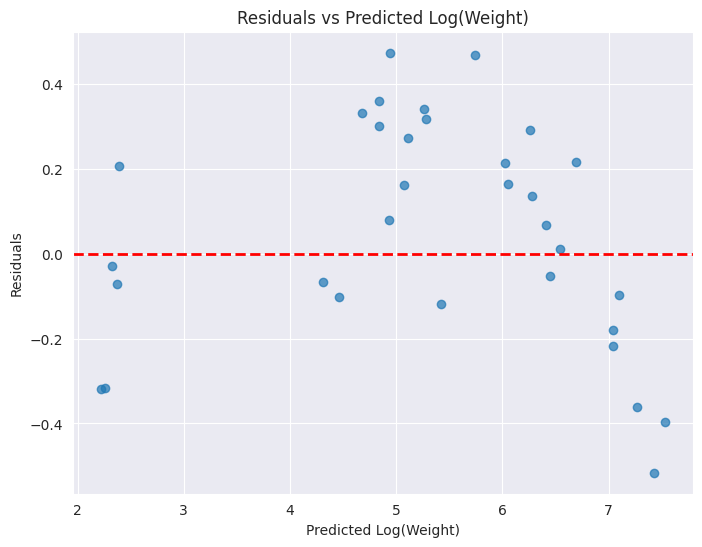

In [67]:
# checking residuals vs fitted values
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Log(Weight)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Log(Weight)')
plt.show()

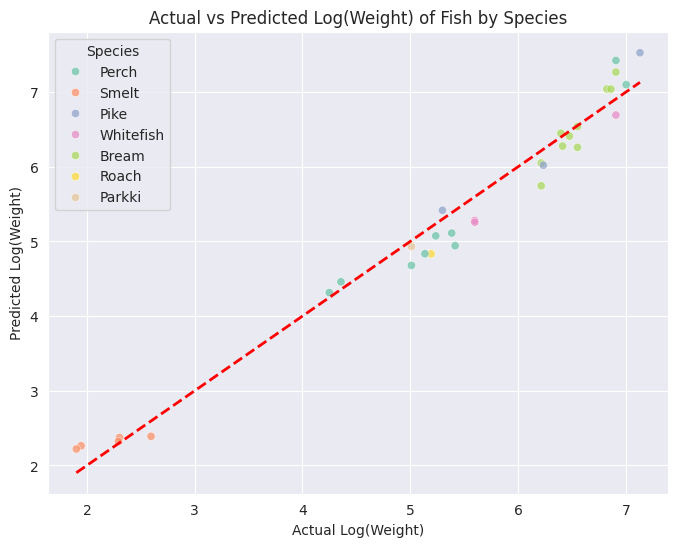

In [69]:
# clour the point in the plot by Species
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, hue=X_test['Species'], palette='Set2', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Log(Weight)')
plt.ylabel('Predicted Log(Weight)')
plt.title('Actual vs Predicted Log(Weight) of Fish by Species')
plt.legend(title='Species')
plt.show()

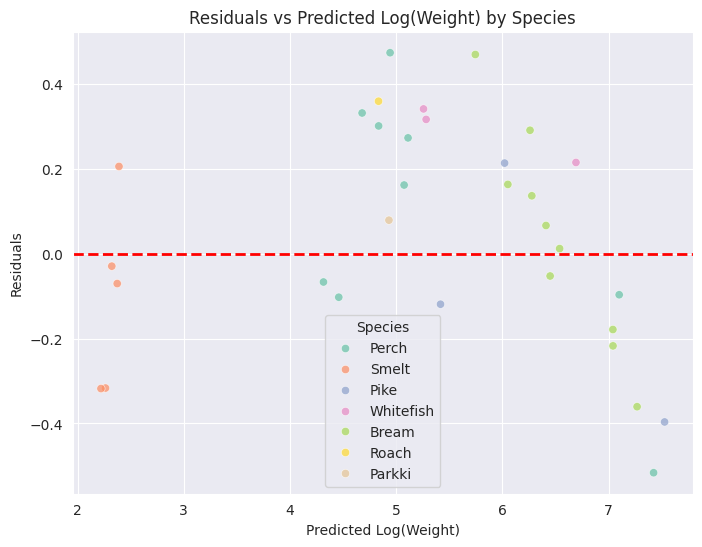

In [70]:
# same for residuals vs fitted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, hue=X_test['Species'], palette='Set2', alpha=0.7)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Log(Weight)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Log(Weight) by Species')
plt.legend(title='Species')
plt.show()

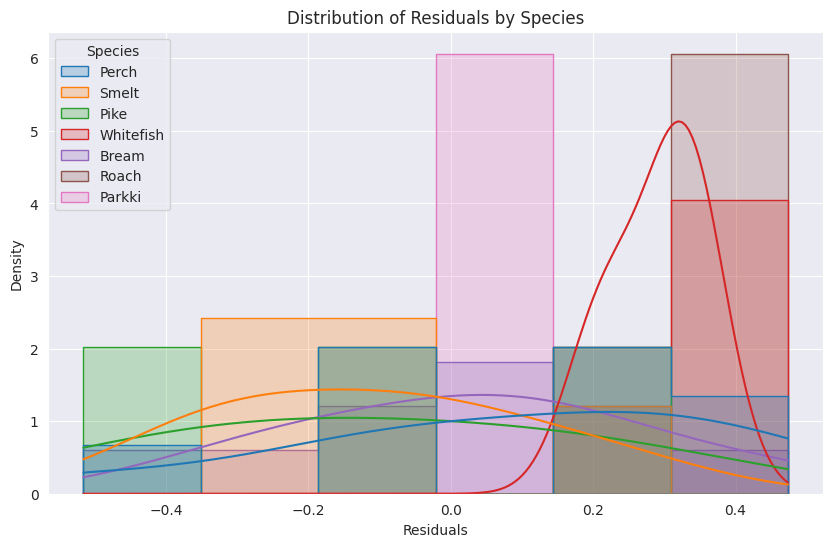

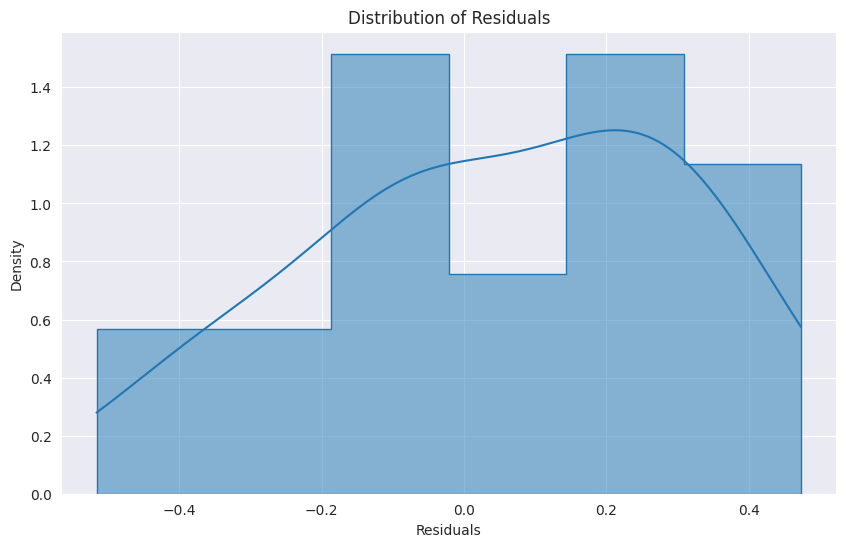

In [72]:
# histogram of residuals by Species
plt.figure(figsize=(10, 6))
sns.histplot(data=pd.DataFrame({'Residuals': residuals, 'Species': X_test['Species']}), x='Residuals', hue='Species', kde=True, element='step', stat='density', common_norm=False)
plt.title('Distribution of Residuals by Species')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.show()

# without categorisation bz species
plt.figure(figsize=(10, 6))
sns.histplot(data=pd.DataFrame({'Residuals': residuals}), x='Residuals', kde=True, element='step', stat='density', common_norm=False)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.show()

In [68]:
fish_df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,5.488938,23.2,25.4,30.0,11.5200,4.0200
1,Bream,5.669881,24.0,26.3,31.2,12.4800,4.3056
2,Bream,5.828946,23.9,26.5,31.1,12.3778,4.6961
3,Bream,5.894403,26.3,29.0,33.5,12.7300,4.4555
4,Bream,6.063785,26.5,29.0,34.0,12.4440,5.1340


In [73]:
# compare with null model using AIC
import statsmodels.api as sm

# Fit the null model (intercept only)
null_model = sm.OLS(y_train, sm.add_constant(np.ones_like(y_train))).fit()

# Fit the full model
full_model = sm.OLS(y_train, sm.add_constant(X_train_processed)).fit()

# Compare AIC values
print(f"Null Model AIC: {null_model.aic}")
print(f"Full Model AIC: {full_model.aic}")
X_train_sm = sm.add_constant(X_train_processed)
model_sm = sm.OLS(y_train, X_train_sm).fit()

Null Model AIC: 435.9328445155188
Full Model AIC: 188.68932789819513


Plots
- scatterplot with regression line
- actual vs. predicted values
- histogram of residuals: normal distribution? → if not, investigate why not?
